# Pronóstico de la Tasa Representativa del Mercado: modelos ARIMA, SARIMA y GARCH

En este notebook se integra el desarrollo de las unidades previas del proyecto sobre la Tasa Representativa del Mercado (TRM). En la unidad 1 se estableció que la serie en nivel no es estacionaria y que su primeria diferencia logarítmica sí lo es, mientras que en la unidad 2 se identificó un modelo MA(1) sobre el log retorno del promedio mensual, cuya estructura se asoció al efecto de agregación temporal (Working, 1960). A partir de esto, en esta unidad se incorporan los modelos ARIMA y SARIMA en la identificación, se revisan los rezagos estacionales de la serie, se incluyen los modelos ARCH y GARCH para la varianza y finalmente se evalúa la capacidad del modelo del avance 2 y del modelo final frente a una caminara aleatoria.

**Fuente de datos:** Banco de la República (2026). Serie diaria de la TRM, noviembre de 1991 a agosto de 2026.


---
## Preparación del entorno

La estimación de los modelos ARIMA y SARIMA se realiza con statsmodels (Seabold & Perkold, 2010) y la de los modelos GARCH con la librería arch (Sheppard, 2025).

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Manejo de datos
import itertools
import numpy as np
import pandas as pd
from scipy import stats

# Visualización 
import matplotlib.pyplot as plt
import seaborn as sns

# Series de tiempo
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from arch import arch_model

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Construcción de la serie mensual

La TRM se calcula como el promedio ponderado de las operaciones de compra y venta de dólares de cada jornada (Banco de la República, 2018), y al igual que en la unidad 2, la serie de trabajo corresponde a su promedio mensual. Antes de calcularlo se verifica que cada mes cuente con la totalidad de sus días, ya que un promedio construido con pocos días no es comparable con el de un mes completo.


In [2]:
url = ("https://raw.githubusercontent.com/Juanhv24/Time-Series-Colombia/"
       "main/data/raw/Tasa%20de%20cambio%20del%20peso%20colombiano.csv")

trm = pd.read_csv(url)
trm.columns = ["fecha", "trm"]
trm["fecha"] = pd.to_datetime(trm["fecha"], format="%Y/%m/%d")
trm = trm.sort_values("fecha").set_index("fecha")["trm"]

# Días con dato frente a días calendario de cada mes
dias = trm.resample("MS").size()
completo = dias == dias.index.days_in_month

incompletos = pd.DataFrame({"días con dato": dias[~completo],
                            "días del mes": dias[~completo].index.days_in_month})
print("Meses incompletos")
print(incompletos.to_string())

# Log-retorno del primer mes con el promedio de noviembre de 1991 incluido
promedio_todos = trm.resample("MS").mean()
primer_retorno = 100 * np.log(promedio_todos.iloc[1] / promedio_todos.iloc[0])
print(f"\nLog-retorno de diciembre de 1991 frente al promedio de 4 días de noviembre: {primer_retorno:.2f}")

Meses incompletos
            días con dato  días del mes
fecha                                  
1991-11-01              4            30
2026-08-01             28            31

Log-retorno de diciembre de 1991 frente al promedio de 4 días de noviembre: -9.64


In [3]:
# Promedio mensual sobre meses completos, en logaritmo y escala porcentual
trm_mensual = trm.resample("MS").mean()[completo]
X = 100 * np.log(trm_mensual)
X.index.freq = "MS"

# Primeria diferencia: log-retorno mensual, serie modelada en la unidad 2
y = X.diff().dropna()

print(f"Periodo: {X.index.min().date()} a {X.index.max().date()} | meses: {len(X)}")
print(f"Observaciones del log-retorno mensual: {len(y)}")

Periodo: 1991-12-01 a 2026-07-01 | meses: 416
Observaciones del log-retorno mensual: 415


**Interpretación:** A partir de la salida podemos observar que los dos meses de los extremos de la serie se encuentran incompletos, por un lado, noviembre de 1991 cuenta con 4 de sus 30 días, mientras que por otro lado agosto de 2026 cuenta con 28 de sus 31 días. En el caso de noviembre, el promedio de solo 4 días genera un log-retorno de -9.64 en diciembre de 1991, valor que en la unidad 2 se reflejó como el residuo de mayor magnitud del modelo. Teniendo en cuenta lo anterior, se optó por excluir ambos meses, por lo que la serie de trabajo queda comprendida entre diciembre de 1991 y julio de 2026, con 416 meses y 415 log-retornos.

# 1. Identificación

## 1.1 Orden de integración

Los modelos ARIMA incorporan la diferenciación dentro de su especificación, por lo que el primer paso de la identificación consiste en determinar el orden $d$ que vuelve estacionaria a la serie (Box et al., 2015). Para esto se aplican de forma conjunta las pruebas ADF y KPSS, cuyas hipótesis nulas son opuestas (Dickey & Fuller, 1979; Kwiatkowski et al., 1992), sobre el log-nivel $X_t = 100\log(\overline{TRM}_t)$ y sobre su diferencia.

In [4]:
def estacionariedad (serie, nombre):
    adf_p = adfuller(serie, autolag="AIC")[1]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_p = kpss(serie, regression="c", nlags="auto")[1]
    # KPSS interpola en una tabla acotada entre 0.01 y 0.10
    kpss_txt = "<0.01" if kpss_p <= 0.01 else ("> 0.10" if kpss_p >= 0.10 else f"{kpss_p:.4f}")
    estacionaria = adf_p < 0.05 and kpss_p >= 0.05
    return {"Serie": nombre, "ADF p-valor": f"{adf_p:.4f}", "KPSS p-valor": kpss_txt,
            "Conclusión": "estacionaria" if estacionaria else "no estacionaria"}

print(pd.DataFrame([estacionariedad(X, "Log-nivel (d = 0)"),
                    estacionariedad(y, "Primera diferencia (d = 1)")]).to_string(index=False))

                     Serie ADF p-valor KPSS p-valor      Conclusión
         Log-nivel (d = 0)      0.1002        <0.01 no estacionaria
Primera diferencia (d = 1)      0.0000       0.0703    estacionaria


**Interpretación:** Los resultados muestran que en el log-nivel la prueba ADF no rechaza la raíz unitaria, con un p-valor de 0.1002 y la prueba KPSS rechaza estacionariedad con un p-valor inferior a 0.01, mientras que en la primera diferencia ambos coinciden en clasificar la serie como estacionaria, con p-valores 0.0000 y 0.0703 respectivamente. Por ende, el orden de integración es $d = 1$. Esto tiene una consecuencia directa sobre la lectura de la unidad 2, ya que el log-retorno corresponde a la primera diferencia del log-nivel, con $y_t = X_t – X_{t-1}$. Al remplazar esta expresión en el MA(1) de la unidad 2 se obtiene $X_t – X_{t-1} = c + \varepsilon_t + \theta\varepsilon_{t-1}$, que es la definición de un ARIMA(0, 1, 1) sobre el log-nivel (Box et al., 2015). Lo que quiere decir que no se trata de un modelo nuevo, sino del mismo modelo expresado sobre el nivel, lo cual resulta necesario en esta unidad para obtener el pronóstico directamente en pesos por dólar. 

## 1.2 Rezagos simples y estacionales en la ACF y la PACF

Debido a que se esta trabajando con la serie del promedio mensual, los patrones anuales deberían manifestarse en los rezagos múltiplos de 12, por lo que a diferencia de la unidad 2, en la que se emplearon 24 rezagos centrados en la estructura regular, en esta unidad se amplía el análisis a 48 rezagos con el fin de evaluar la parte estacional en cuatro ciclos anuales, ciclos que están marcados con líneas punteadas en la gráfica. Adicionalmente, la gráfica se acompaña con los valores numéricos y el umbral de significancia $\pm 1.96/\sqrt{n}$, calculado bajo la hipótesis nula de ruido blanco (Box et al., 2015)

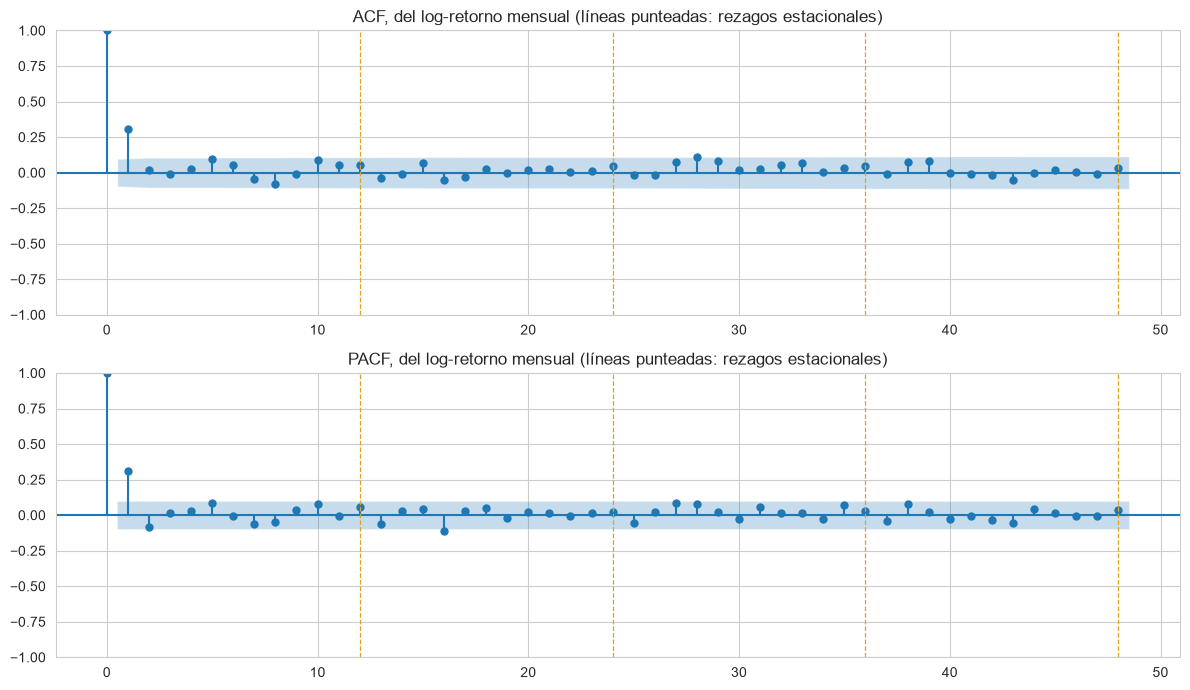

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(y, lags=48, ax=axes[0])
plot_pacf(y, lags=48, ax=axes[1])

for ax, nombre in zip(axes, ["ACF", "PACF"]):
    for k in (12, 24, 36, 48):
        ax.axvline(k, color="goldenrod", linestyle="--", linewidth=0.9)
    ax.set_title(f"{nombre}, del log-retorno mensual (líneas punteadas: rezagos estacionales)")

plt.tight_layout()
plt.savefig("../reports/figures/13_acf_pacf_estacional.png", dpi=150)
plt.show()

In [6]:
n = len(y)
banda = 1.96 / np.sqrt(n)
a = acf(y, nlags=48)
p = pacf(y, nlags=48)

tabla_rezagos = pd.DataFrame({"rezago":[1, 12, 24, 36, 48],
                              "tipo": ["simple"] + ["estacional"] * 4})
tabla_rezagos["ACF"] = [round(a[k], 4) for k in tabla_rezagos["rezago"]]
tabla_rezagos["PACF"] = [round(p[k], 4) for k in tabla_rezagos["rezago"]]

print(f"n = {n} | umbral de significancia = ±{banda:.4f}\n")
print(tabla_rezagos.to_string(index=False))

sig_acf = [k for k in range(1, 49) if abs(a[k]) > banda]
sig_pacf = [k for k in range(1, 49) if abs(p[k]) > banda]
print(f"\nRezagos fuera del umbral (de 48) -> ACF: {sig_acf} | PACF: {sig_pacf}")
print(f"Rezagos esperados fuera del umbral por azar, al 5%: {0.05 * 48:.1f} por función")

n = 415 | umbral de significancia = ±0.0962

 rezago       tipo    ACF   PACF
      1     simple 0.3087 0.3094
     12 estacional 0.0536 0.0591
     24 estacional 0.0431 0.0234
     36 estacional 0.0434 0.0350
     48 estacional 0.0323 0.0381

Rezagos fuera del umbral (de 48) -> ACF: [1, 28] | PACF: [1, 16]
Rezagos esperados fuera del umbral por azar, al 5%: 2.4 por función


**Interpretación:** Con lo que respecta a los rezagos simples, tanto la ACF como la PACF presentan un coeficiente dominante en el primer rezago, con valores de 0.3087 y 0.3094, lo que indica una estructura de orden uno en la parte regular, igual a lo que se identificó en la unidad 2. Por otro lado,  en los rezagos estacionales 12, 24, 36, y 48 ningún coeficiente supera el umbral de ±0.0962, siendo el mayor PACF en el rezago 12 con 0.0591. A pesar de esto, fuera del primer rezago aparecen dos valores aislados por encima del umbral, el rezago de 28 en la ACF y el 16 en la PACF, sin embargo, con 48 rezagos evaluados el 5 % se esperan 2.4 por azar en cada función y ninguno de los dos corresponde a un múltiplo de 12, por lo que no constituye evidencia de un patrón estacional.

## 1.3 ¿Requiere la serie una diferenciación estacional?

Dado que la ACF no muestra picos en los rezagos estacionales, se evalúa de manera formal si es necesario aplicar una diferenciación estacional $D = 1$. Para esto se contrastan dos elementos, por un lado la prueba de Kruskal-Wallis, que compara la distribución del log-retorno entre los doce meses del año sin suponer normalidad (Kruskal-Wallis, 1952), y por otor lado, el efecto que tendría imponer $D = 1$ sobre la serie. 


In [7]:
# Efecto calendario: distribución del log-retorno por mes del año
grupos = [y[y.index.month == mes] for mes in range(1, 13)]
kw = stats.kruskal(*grupos)
print(f"Kruskal-Wallis por mes: H = {kw.statistic:.2f} | p-valor = {kw.pvalue:.4f}")

# Consecuencia de imponer una diferencia estacional (D = 1) sobre esta serie
y_D = X.diff().diff(12).dropna()
print(f"ACF en el rezago 12 con d = 1 y D = 1: {acf(y_D, nlags=12)[12]:.4f}")

modelo_D = SARIMAX(X, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
print(f"Coeficiente MA estacional estimado con D = 1: {modelo_D.params['ma.S.L12']:.4f}")

Kruskal-Wallis por mes: H = 16.54 | p-valor = 0.1221
ACF en el rezago 12 con d = 1 y D = 1: -0.4831
Coeficiente MA estacional estimado con D = 1: -0.9128


**Interpretación:** La prueba de Kruskal-Wallis no rechaza la igualdad de las distribuciones entre meses, con un p-valor de 0.1221, lo que quiere decir que no existe evidencia de un efecto calendario en el log-retorno mensual. Por otro lado, al imponer $D=1$ la ACF en el rezago 12 toma un valor de -0.4831, cercano al -0.5 que se obtiene por construcción al diferenciar estacionalmente una serie sin componente estacional, ya que la covarianza entre $\varepsilon_t-\varepsilon_{t-12}$ y $\varepsilon_{t-12}-\varepsilon_{t-24}$ es $-\sigma^2$ mientras que la varianza de cada termino es $2\sigma^2$. Además, el coeficiente MA estacional estimado es de -0.9128, próximo a -1, siendo este el síntoma característico de una sobre diferenciación, que introduce una raíz unitaria en la parte de media móvil (Plosser & Schwert, 1997). Teniendo en cuenta lo anterior, se fija $D=0$. 

## 1.4 Modelos candidatos y su expresión matemática
Con lo que respecta a la selección de candidatos, esta se acota a lo observado en ACF y PACF. Por un lado, en la parte regular el único rezago significativo es el primero, por lo que los órdenes se limitan a $p, q \in \{0,1\}$. Mientras que en la parte estacional no se observan coeficientes significativos, sin embargo, se incluyen los órdenes $P, Q \in \{0,1\}$ con el fin de verificar de manera formal que el componente estacional no aporta a la especificación, además, la diferenciación se mantiene en $d=1$ y $D=0$ por lo obtenido en las secciones 1.1 y 1.3. De esta forma, la grilla contiene 16 especificaciones, entre ellas la caminata aleatoria con deriva, ARIMA(0,1,0).

La forma general de estos modelos corresponde a un SARIMA$(p,d,q)(P,D,Q)_s$ (Box et al., 2015):

$$\phi(L)\,\Phi(L^s)\,(1-L)^d\,(1-L^s)^D X_t = c + \theta(L)\,\Theta(L^s)\,\varepsilon_t$$

Donde $L$ es el operador de rezago, $\phi(L)$ y $\theta(L)$ son los polinomios autorregresivos y de media móvil de la parte regular, $\Phi(L^s)$ y $\Theta(L^s)$ los de la parte estacional con $s=12$, $c$ es la contante y $\varepsilon_t$ es ruido blanco. Cuando $P=Q=D=0$ la expresión se reduce a un ARIMA$(p,d,q)$.


# 2. Estimación

## 2.1 Grilla de modelos candidatos 

En este caso, cada especificación se compara mediante log-verosimilitud, que mide el ajuste y los criterios de información de Akaike (1974) y de Schwarz (1979), que penalizan el número de parámetros, siendo Schwarz el más severo. A partir de esto, se obtiene como resultado una tabla que se ordena por BIC y reporta los coeficientes que no alcanzan una significancia al 5 %.

In [8]:
filas = []

for p_ord, q_ord, P, Q, in itertools.product((0, 1), repeat=4):
    ajuste = SARIMAX(X, order=(p_ord, 1, q_ord), seasonal_order=(P, 0, Q, 12),
                     trend="c").fit(disp=False)
    coef = ajuste.pvalues.drop("sigma2")
    nombre = (f"ARIMA({p_ord},1,{q_ord})" if P == Q == 0
              else f"SARIMA({p_ord},1,{q_ord})({P},0,{Q})12")
    filas.append({
        "Modelo": nombre,
        "k": len(ajuste.params),
        "Log-verosimilitud": round(ajuste.llf, 2),
        "AIC": round(ajuste.aic, 2),
        "BIC": round(ajuste.bic, 2),
        "Coef. no significativos": ", ".join(coef.index[coef>=0.05]) or "ninguno"
    })

grilla = pd.DataFrame(filas).sort_values("BIC").reset_index(drop=True)
print("k: número de parámetros estimados, incluida la varianza del error\n")
print(grilla.to_string(index=False))

k: número de parámetros estimados, incluida la varianza del error

                Modelo  k  Log-verosimilitud     AIC     BIC    Coef. no significativos
          ARIMA(0,1,1)  3           -1007.93 2021.87 2033.95                    ninguno
          ARIMA(1,1,0)  3           -1009.09 2024.17 2036.26                  intercept
SARIMA(0,1,1)(1,0,0)12  4           -1007.01 2022.02 2038.13        intercept, ar.S.L12
SARIMA(0,1,1)(0,0,1)12  4           -1007.09 2022.18 2038.29        intercept, ma.S.L12
          ARIMA(1,1,1)  4           -1007.74 2023.48 2039.59           intercept, ar.L1
SARIMA(1,1,0)(1,0,0)12  4           -1008.36 2024.71 2040.83        intercept, ar.S.L12
SARIMA(0,1,1)(1,0,1)12  5           -1005.36 2020.71 2040.85                  intercept
SARIMA(1,1,0)(0,0,1)12  4           -1008.42 2024.85 2040.96        intercept, ma.S.L12
SARIMA(1,1,0)(1,0,1)12  5           -1006.69 2023.38 2043.52                  intercept
SARIMA(1,1,1)(1,0,0)12  5           -1006.83 2023.67 

**Interpretación:** A partir de los resultados observados en la tabla se puede determinar que el modelo que encabeza la grilla por BIC, es un ARIMA(0,1,1) con un valor de 2033.95, que junto con la caminata aleatoria, son los únicos modelos en los que todos los coeficientes resultan significativos . Por otor lado, el menor AIC corresponde al modelo SARIMA(0,1,1)(1,0,1)12, con 2020.71 sin embargo, su BIC de 2040.85 lo ubica en el séptimo lugar, lo anterior indica que la mejora en el ajuste no compensa los parámetros adicionales. Con lo que respecta a la caminata aleatoria, esta presenta el menor ajuste de los modelos sin un componente estacional, con una log-verosimilitud de -1020.17 frente a -1007.93 del modelo ARIMA(0,1,1), lo que confirma que el término de media móvil captura una estructura presente en la muestra.

## 2.2 Pruebas de razón de verosimilitud

En cuanto a los modelos anidados, la diferencia en log-verosimilitud se evalúa mediante la prueba de razón de verosimilitud, cuyo estadístico $LR = 2(\ell_{general} - \ell_{restringido})$ sigue una distribución chi-cuadrado de forma asintótica con tantos grados de libertad como parámetros adicionales tenga el modelo general (Wilks, 1938). Con lo que respecta al ARIMA(0,1,1) se contrastan tres elementos, los términos estacionales, un término AR regular y la constante.

In [10]:
def razon_verosimilitud(restringido, general, contraste):
    lr = 2 * (general.llf - restringido.llf)
    gl = len(general.params) - len(restringido.params)
    return {"Contraste": contraste, "LR": round(lr, 3), "gl": gl,
            "p-valor": round(stats.chi2.sf(lr, gl), 4)}

arima_011 = SARIMAX(X, order=(0, 1, 1), trend="c").fit(disp=False)
arima_011_sin_c = SARIMAX(X, order=(0, 1, 1), trend="n").fit(disp=False)
arima_111 = SARIMAX(X, order=(1, 1, 1), trend="c").fit(disp=False)
sarima_101 = SARIMAX(X, order=(0, 1, 1), seasonal_order=(1, 0, 1, 12), trend="c").fit(disp=False)

print(pd.DataFrame([
    razon_verosimilitud(arima_011, sarima_101, "AR y MA estacionales"),
    razon_verosimilitud(arima_011, arima_111, "AR regular"),
    razon_verosimilitud(arima_011_sin_c, arima_011, "Constante"),
]).to_string(index=False))

print("\nCoeficientes estacionales del SARIMA(0,1,1)(1,0,1)12:")
print(sarima_101.params[["ar.S.L12", "ma.S.L12"]].round(4).to_string())
print(f"\nSin constante -> AIC = {arima_011_sin_c.aic:.2f} | BIC = {arima_011_sin_c.bic:.2f}")
print(f"Con constante -> AIC = {arima_011.aic:.2f} | BIC = {arima_011.bic:.2f}")

           Contraste    LR  gl  p-valor
AR y MA estacionales 5.154   2   0.0760
          AR regular 0.389   1   0.5326
           Constante 4.817   1   0.0282

Coeficientes estacionales del SARIMA(0,1,1)(1,0,1)12:
ar.S.L12    0.8377
ma.S.L12   -0.7751

Sin constante -> AIC = 2024.68 | BIC = 2032.74
Con constante -> AIC = 2021.87 | BIC = 2033.95


**Interpretación:** Con lo que respecta a los términos estacionales, se evidencia que estos no resultan significativos en conjunto, con un p-valor de 0.0760 y tampoco el término AR regular, con un p-valor de 0.5326. En el caso del modelo SARIMA(0,1,1)(1,0,1)12, sus coeficientes estacionales de 0.8377 y -0.7751 son de magnitud similar, de tal forma que los factores $(1-0.8377L^{12})$ de la parte autorregresiva y $(1-0.7751L^{12})$ de la parte de media móvil tienden a cancelarse, siendo esta una señal de redundancia de parámetros (Box et al., 2015) que explica por qué el menor AIC de la grilla se traduce en una especificación útil.

Por otro lado, la constante si resulta significativa, con un p-valor de 0.0282 y su inclusión reduce el AIC de 2024.68 a 2021.87, mientras que el BIC aumenta ligeramente de 2032.74 a 2033.95, lo cual se debe a la mayor penalización que este criterio aplica por parámetro. Teniendo en cuenta que la prueba de razón de verosimilitud y de AIC favorecen la constante, esta se conserva en el modelo, lo cual mantiene además la especificación seleccionada en la unidad 2.


## 2.3 Modelo seleccionado

In [11]:
modelo_media = arima_011
print(modelo_media.summary().tables[1])
print(f"\nLog-verosimilitud = {modelo_media.llf:.2f} | AIC = {modelo_media.aic:.2f} | BIC = {modelo_media.bic:.2f}")

# Autocorrelación de primer orden implicada por el MA(1): theta / (1 + theta^2)
theta = modelo_media.params["ma.L1"]
print(f"ACF(1) implicada por el modelo: {theta / (1 + theta**2):.4f} | ACF(1) observada: {a[1]:.4f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3946      0.191      2.067      0.039       0.020       0.769
ma.L1          0.3277      0.036      8.981      0.000       0.256       0.399
sigma2         7.5335      0.379     19.891      0.000       6.791       8.276

Log-verosimilitud = -1007.93 | AIC = 2021.87 | BIC = 2033.95
ACF(1) implicada por el modelo: 0.2959 | ACF(1) observada: 0.3087


**Interpretación:** A partir de los resultados, el modelo seleccionado es un ARIMA(0, 1, 1) con constante, cuyos coeficientes resultan significativos al 5 %, con un término de media móvil de 0.3277 y una constante de 0.3946, lo cual representa la depreciación promedio mensual del peso en el periodo analizado. Remplazando los valores estimados en la forma general de la sección 1.4 con $p=0$, $d=1$ y $q=1$, se obtiene el modelo resultante

$$(1-L)X_t = 0.3946 + (1+0.3277L)\,\varepsilon_t$$

De forma equivalente se expresa como 

$$X_t = X_{t-1} + 0.3946 + \varepsilon_t + 0.3277\,\varepsilon_{t-1}, \qquad \hat{\sigma}^2 = 7.5335$$

Donde $X_t = 100\log(\overline{TRM}_t)$. A diferencia de lo observado en la unidad 2, la constante pasa a ser significativa, con un p-valor de 0.039 frente a 0.061, cambio que se relaciona con la exclusión del mes incompleto de noviembre de 1991 y su log-retorno de -9.64. Adicionalmente, la autocorrelación de primer orden que implica el modelo, $\theta/(1+\theta^2)$ (Box et al., 2015), es de 0.2959, cercana tanto a la observada de 0.3087 como al 0.25 que predice el efeto de agregación temporal (Working, 1960).